In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
os.environ['PYTHONPATH'] = ':'.join(sys.path)

In [2]:
import numpy as np
import hgpflow_v2.performance # don't know why this is needed, but it is
from hgpflow_v2.performance.performance import PerformanceCOCOA
from copy import deepcopy

## qqbar samples I generated 

In [3]:
from hgpflow_v2.performance.performance import PerformanceCOCOA
from hgpflow_v2.performance.plot_helper_event import compute_jet_residual_dict, plot_jet_residuals

RUN = '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25'

perf = PerformanceCOCOA(
    truth_path='/pscratch/sd/a/agolub/qqbar_events/combined_root_files/combined_qqbar_105k.root',
    pred_path=f'{RUN}/inference/fullval/pred_*_merged.root',
    ind_threshold=0.4,
    event_number_offset=250000)   # your splitter's -eo OFFSET for this file


Computing HGPFlow mass...: 100%|██████████| 10000/10000 [00:00<00:00, 29146.14it/s]


E, pT will be scaled by 0.001
no pflow_* branches in this file -> skipping PPflow baseline


Applying fiducial cuts...: 100%|██████████| 105574/105574 [00:00<00:00, 114816.20it/s]
/global/u1/a/agolub/HGPflow/hgpflow_v2/performance/reader.py:178: RuntimeWarning: invalid value encountered in sqrt
  truth_dict['particle_mass'].append(np.sqrt(e**2 - p**2))


common event count: 10000


Filtering and reordering HGPFlow...: 100%|██████████| 12/12 [00:00<00:00, 6852.50it/s]


Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
truth


Computing jets...:   0%|          | 1/10000 [00:00<24:13,  6.88it/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


Computing jets...: 100%|██████████| 10000/10000 [00:56<00:00, 177.00it/s]


proxy


Computing jets...: 100%|██████████| 10000/10000 [01:16<00:00, 130.63it/s]


hgpflow


Matching jets...: 100%|██████████| 10000/10000 [00:00<00:00, 32520.44it/s]


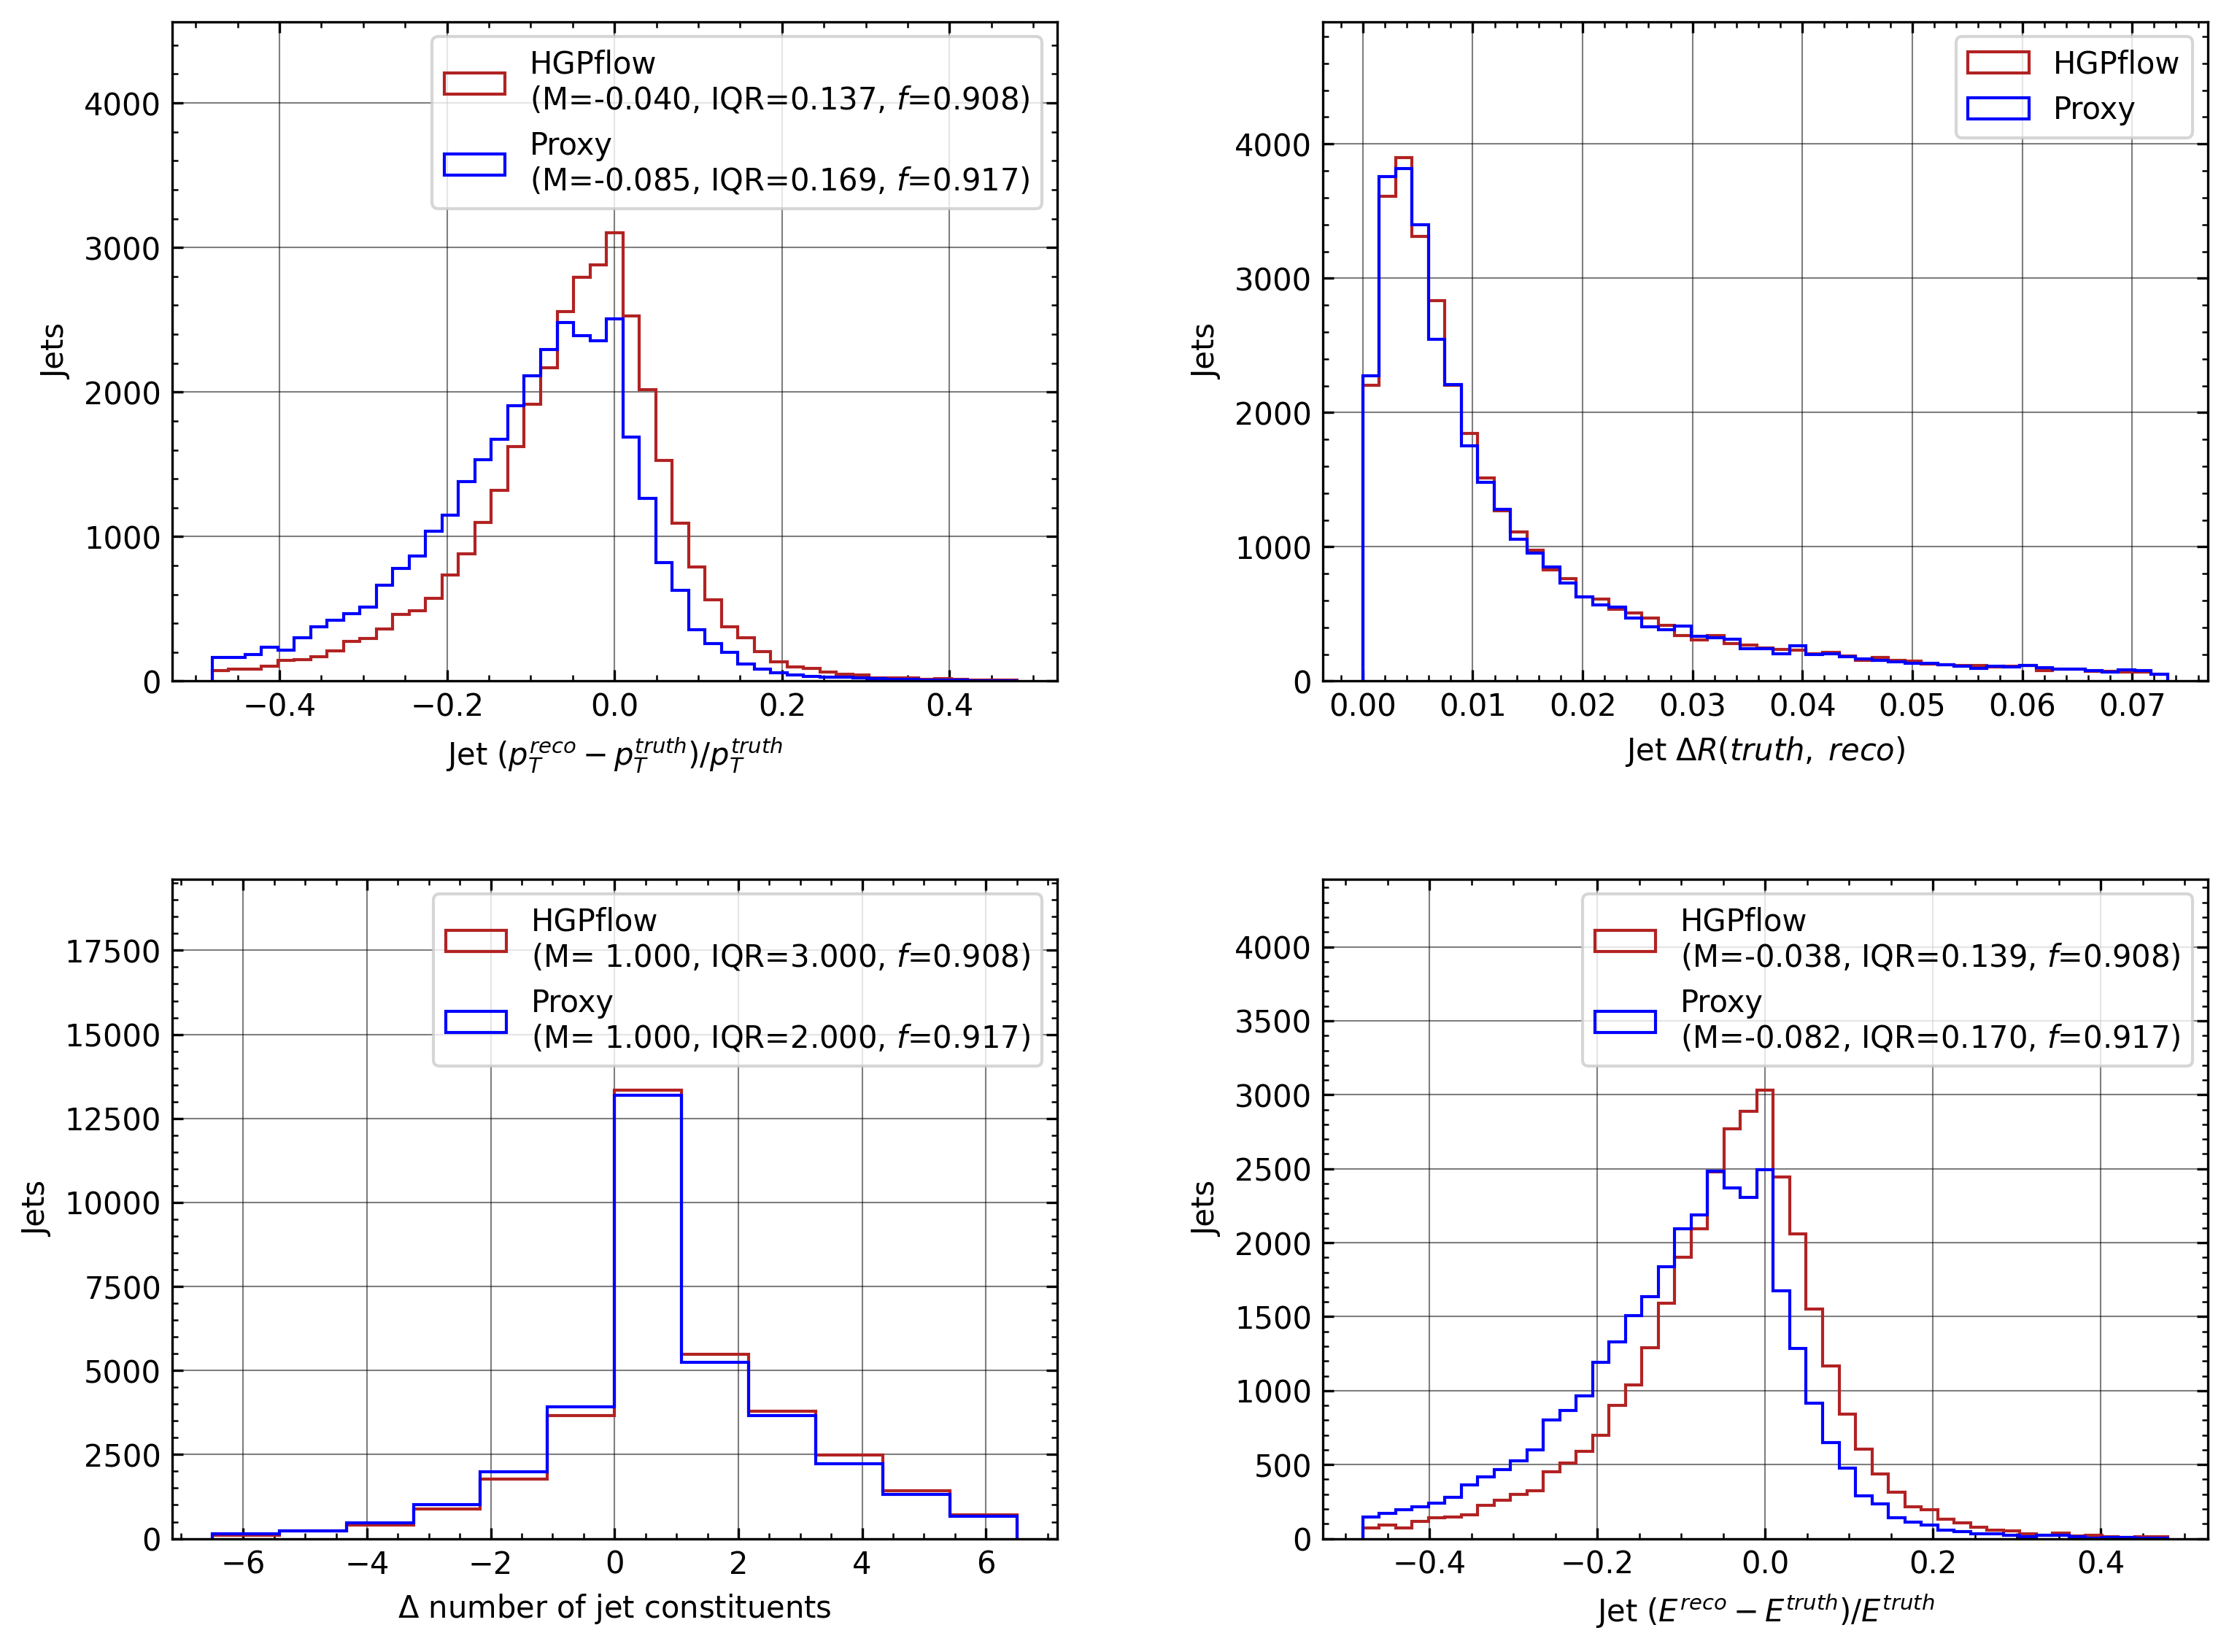

In [4]:
# Proxy comparison instead of ppflow as the comparison curve
perf.compute_jets(radius=0.4, algo='antikt')
perf.match_jets()
residual_dict = compute_jet_residual_dict({
    'hgpflow': perf.hgpflow_dict['matched_hgpflow_jets'],
    'proxy'  : perf.hgpflow_dict['matched_proxy_jets'],
})



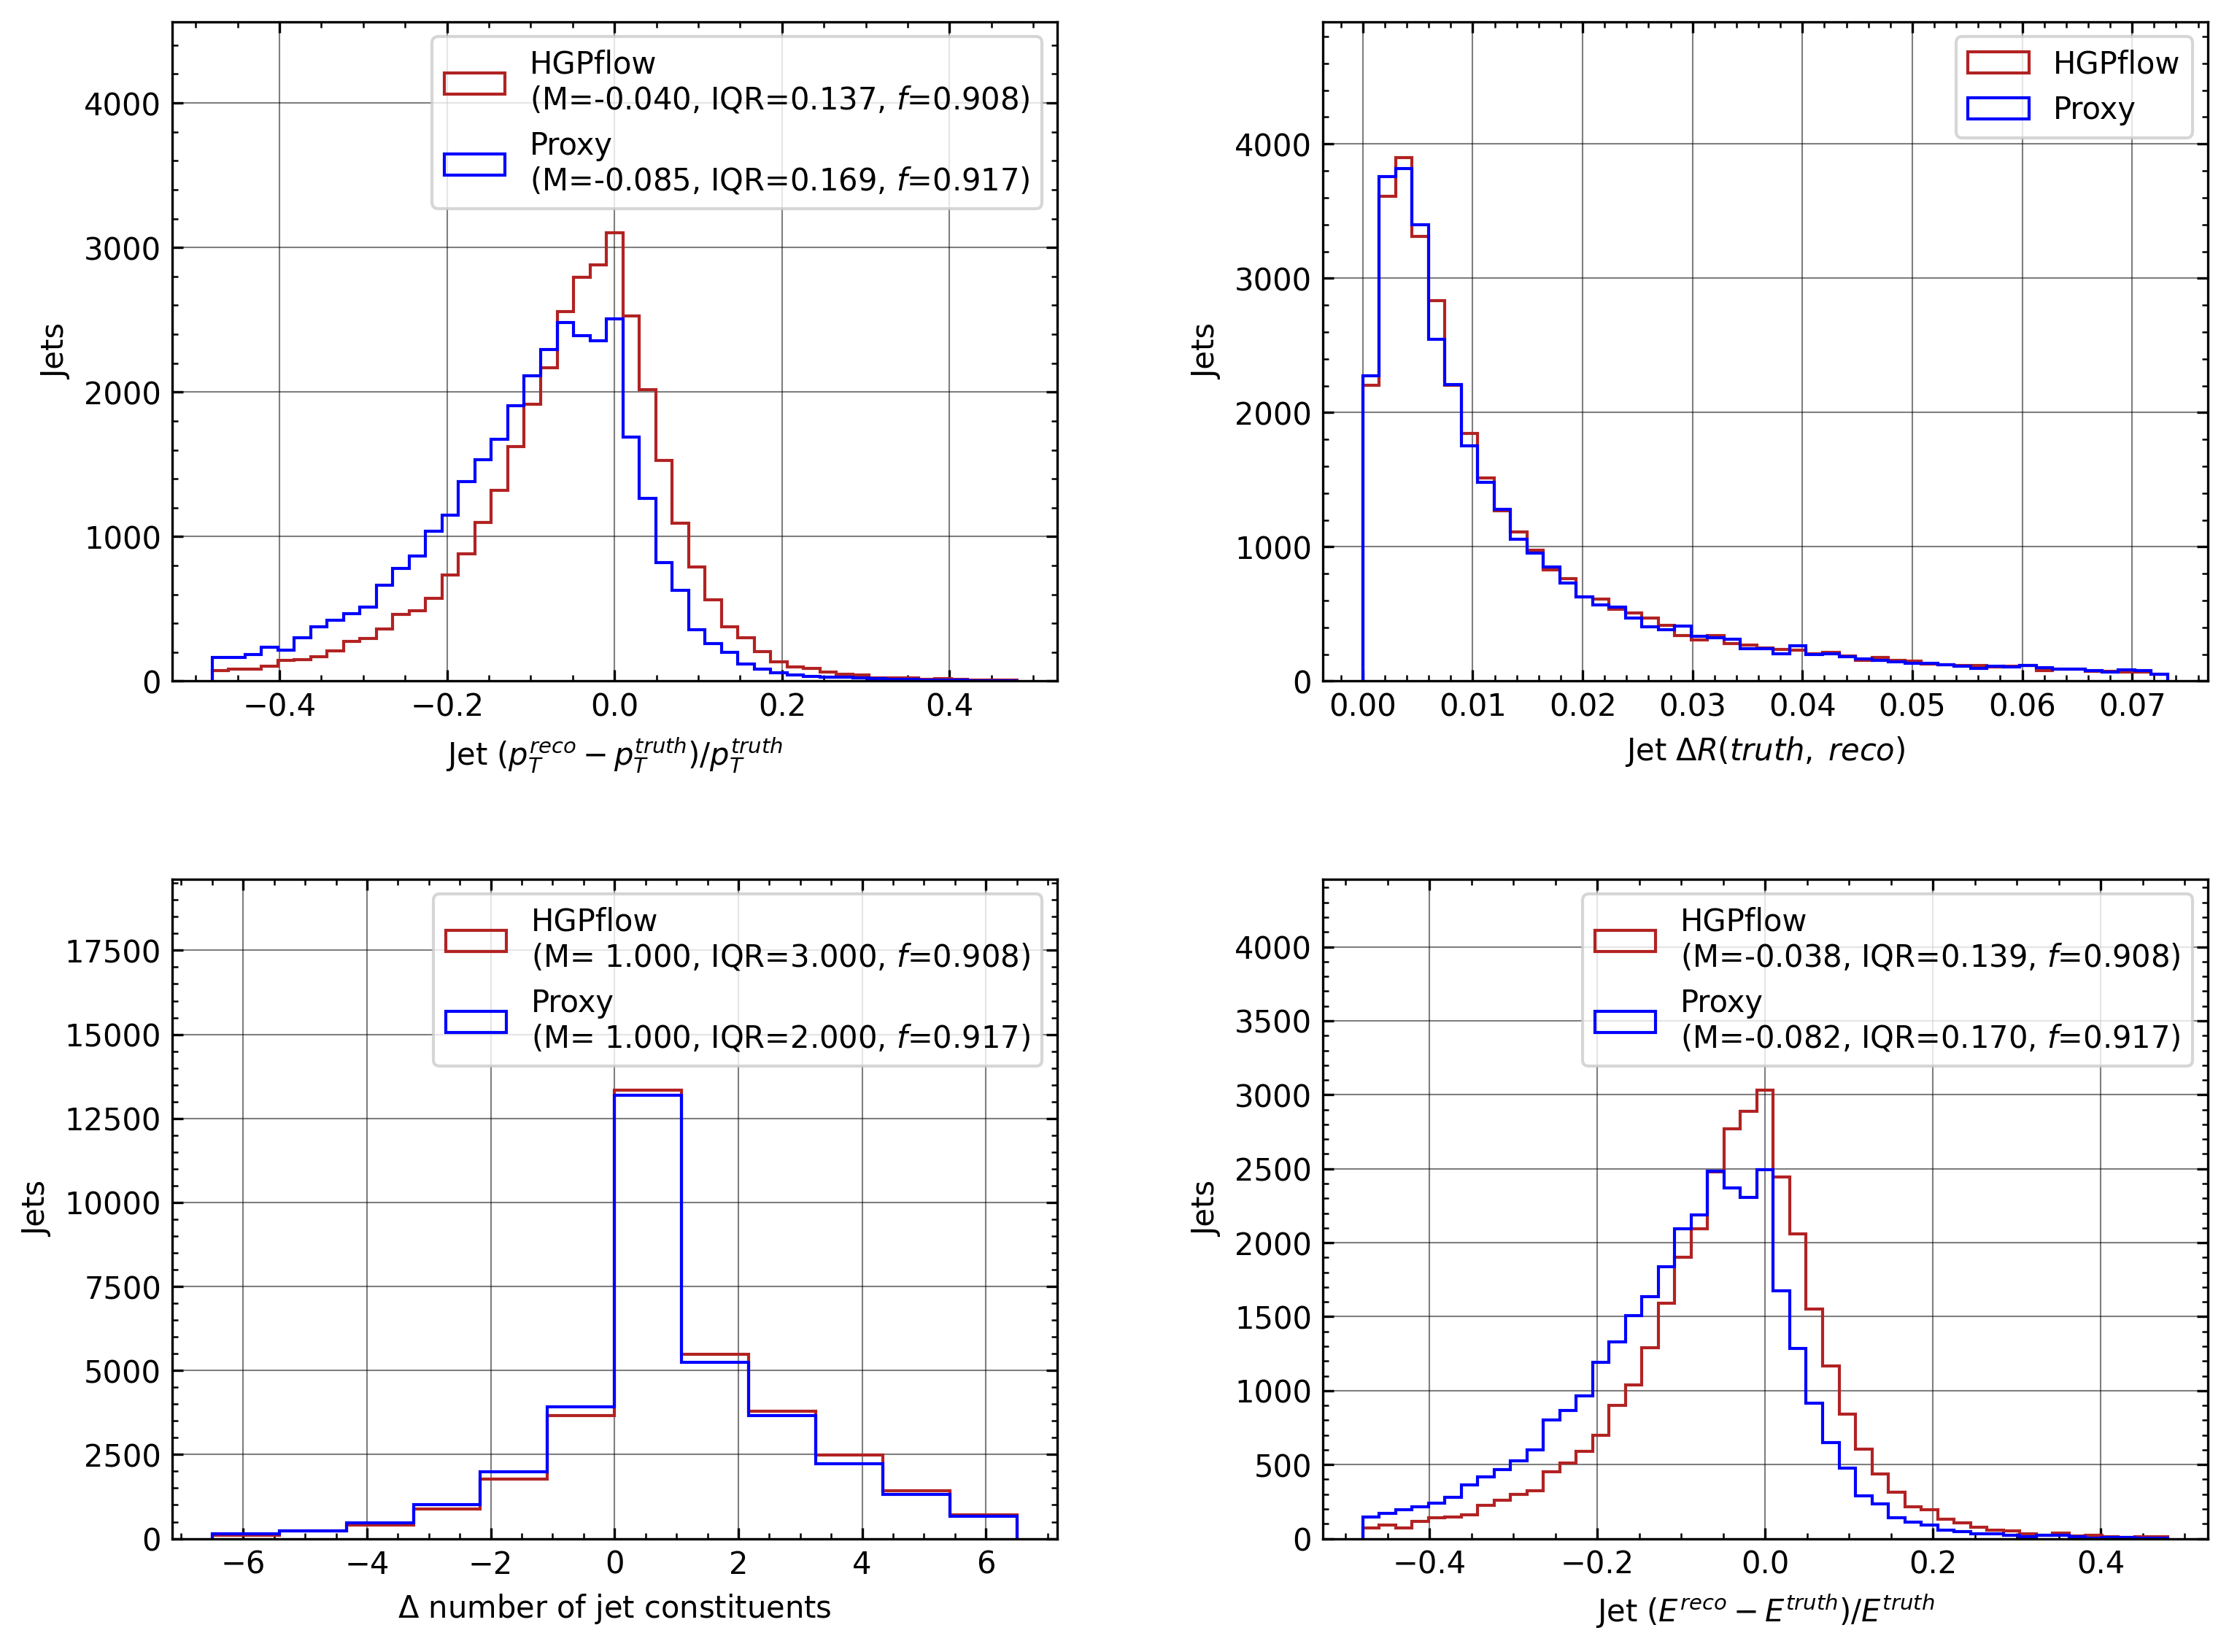

In [5]:
fig = plot_jet_residuals(residual_dict, pt_relative=True)

In [6]:
perf.hgpflow_dict['hgpflow_eta'] = perf.hgpflow_dict['proxy_eta']
perf.hgpflow_dict['hgpflow_phi'] = perf.hgpflow_dict['proxy_phi']

for i in range(len(perf.hgpflow_dict['hgpflow_pt'])):
    ch_mask = perf.hgpflow_dict['hgpflow_class'][i] <= 2
    perf.hgpflow_dict['hgpflow_pt'][i][ch_mask] = perf.hgpflow_dict['proxy_pt'][i][ch_mask]

In [7]:
perf.compute_jets(n_procs=30)
perf.match_jets()

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
truth
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4


Computing jets...:   0%|          | 0/333 [00:00<?, ?it/s]

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4


Computing jets...:   0%|          | 0/333 [00:00<?, ?it/s]

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4


...

Computing jets...: 100%|██████████| 333/333 [00:02<00:00, 128.57it/s]

antikt
Jet clustering radius: 

Computing jets...:  72%|███████▏  | 239/333 [00:02<00:00, 121.36it/s]

 0.4


Matching jets...: 100%|██████████| 10000/10000 [00:00<00:00, 18380.58it/s]


In [8]:
from hgpflow_v2.performance.plot_helper_event import compute_jet_residual_dict

_dict = {
    'ppflow': perf.truth_dict['matched_ppflow_jets'],
    'hgpflow': perf.hgpflow_dict['matched_hgpflow_jets'],
}

jet_residual_dict = compute_jet_residual_dict(_dict, dr_cut=0.1, leading_N_jets=2, pt_min=10)

KeyError: 'matched_ppflow_jets'